# Customer Churn Prediction Project
Workflow: Problem → Data → EDA → Feature Engineering → Modeling → Evaluation → Insights

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

## 2. Load Dataset

In [11]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Method 1: Uploading Directly to Colab Session

In [2]:
from google.colab import files
import pandas as pd

print("Please select the 'Telco-Customer-Churn.csv' file to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Once uploaded, you can load it like this (assuming it's in the current directory):
# df = pd.read_csv('Telco-Customer-Churn.csv')
# display(df.head())

Please select the 'Telco-Customer-Churn.csv' file to upload:


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
User uploaded file "Telco-Customer-Churn.csv" with length 977501 bytes


#### Method 2: Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, navigate to your file's location in Google Drive. For example:
# The file path would typically be '/content/drive/MyDrive/path/to/your/Telco-Customer-Churn.csv'
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Telco-Customer-Churn.csv') # Example path
# display(df.head())

Once you've successfully uploaded the file or mounted your drive, you'll need to update the cell where you tried to load the data (`zlJ9dIc74Y1e`).

**Please choose one of the methods above, run the cells, and then tell me the correct path to your CSV file.** I can then modify the `pd.read_csv()` call to use the correct path.

## 3. Data Understanding

In [9]:
df.shape
df.info()
df.describe()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Data Cleaning

In [13]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df.isnull().sum()
# print(df['Churn'])
# print(df['Churn'].unique())

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


4.1 creating training and test datasets used for group analysis ...from original dataframe

In [15]:
X_sample = df.drop(['Churn','customerID'],axis=1)
y_sample = df['Churn']
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(X_sample,y_sample,test_size=0.2,random_state=42)
print(X_train_sample.head(5))
print(y_train_sample.head(5))

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
2142  Female              0      No        Yes      21          Yes   
1623  Female              0      No         No      54          Yes   
6074    Male              0     Yes         No       1           No   
1362    Male              0      No         No       4          Yes   
6754    Male              0      No        Yes       0          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
2142                No             DSL            Yes           No   
1623               Yes     Fiber optic             No          Yes   
6074  No phone service             DSL             No           No   
1362                No     Fiber optic             No           No   
6754               Yes             DSL            Yes          Yes   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
2142              Yes          No          No             Yes        On

## 5. Exploratory Data Analysis

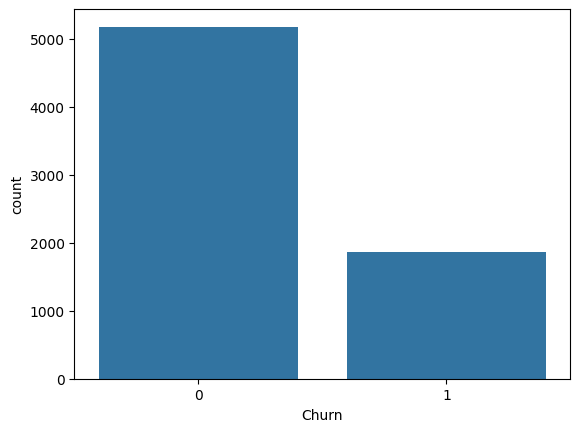

In [16]:
sns.countplot(x='Churn', data=df)
plt.show()

In [17]:
print(df['Churn'].value_counts())
pd.crosstab(df['Contract'], df['Churn'])

Churn
0    5174
1    1869
Name: count, dtype: int64


Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48



Value counts resulted in churn:1869 and not churn 5174. churn percentages: 26.5% ,73.5% . which is moderately imbalanced dataset. we can apply smote and other techniques. cross tab revealed Customers with month-to-month contracts show higher churn compared to yearly contracts.

## 5.2. Data Preprocessing

Handling Missing and Incorrect Values

In [19]:
# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN by assigning back to the column (No more 'inplace=True')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

Handling Categorical Variables

Some features like State, International Plan and Voice Mail Plan are categorical and must be converted into numerical values for model training.

LabelEncoder() converts categorical values into numerical form. Each unique category is assigned a numeric label.
The loop iterates through each categorical column and applies fit_transform() to encode categorical variables into numbers.

In [20]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    df[col] = labelencoder.fit_transform(df[col])

In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


## 6. Feature Engineering

In [22]:
df['charges_per_month'] = df['TotalCharges'] / df['tenure']
print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQITU       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0                0         0                 1   


## 7. Train Test Split

In [23]:
X = df.drop(['Churn','customerID','charges_per_month'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

7.1 Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_1 = scaler.fit_transform(X_train)
X_test_1 = scaler.transform(X_test)

## 8. Model Training

In [25]:
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn import metrics

knn = KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier(n_estimators = 7,
                             criterion = 'entropy',
                             random_state =7)
svc = SVC()
lc = LogisticRegression(max_iter=1000)

# making predictions on the training set
for clf in (rfc, knn, svc,lc):
    clf.fit(X_train_1, y_train)
    y_pred = clf.predict(X_train_1)
    print("Accuracy score of ",
          clf.__class__.__name__,
          "=",100*metrics.accuracy_score(y_train,
                                         y_pred))
# Step 2: Extract feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rfc.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

Accuracy score of  RandomForestClassifier = 97.87007454739084
Accuracy score of  KNeighborsClassifier = 85.58750443734469
Accuracy score of  SVC = 81.93113241036563
Accuracy score of  LogisticRegression = 80.03194888178913
             feature  importance
17    MonthlyCharges    0.184328
18      TotalCharges    0.179070
4             tenure    0.156670
8     OnlineSecurity    0.067710
14          Contract    0.055514
16     PaymentMethod    0.054994
11       TechSupport    0.048082
10  DeviceProtection    0.029128
0             gender    0.028942
15  PaperlessBilling    0.026598


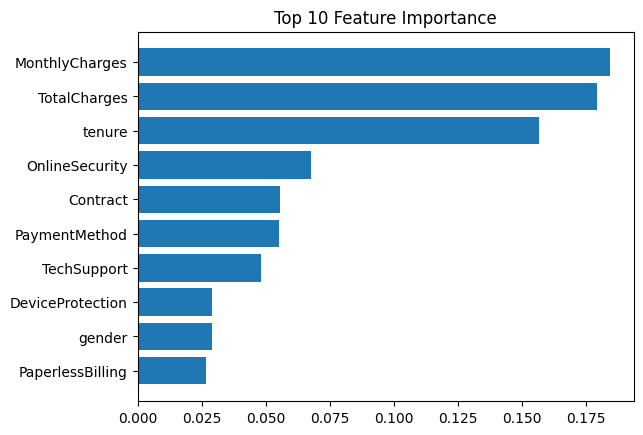

In [26]:
# Step 3: Visualize (this is what interviewers like)
top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

“High monthly charges,Total Charges increase churn probability, suggesting price sensitivity”.
“Lower tenure customers have higher churn, indicating early disengagement”

METHOD 2: Grouped Analysis (THIS is what makes your project strong)

In [27]:
# Step 1: Combine X_train + y_train
feature_list =X.columns
train_df = pd.DataFrame(X_train_sample, columns=feature_list)
train_df['Churn'] = y_train_sample
train_df['Churn'] = train_df['Churn'].astype(int)
print(train_df.head(5))
# Step 2: Analyze categorical variables
# Example: Contract type----This gives churn rate per category
contract_analysis = train_df.groupby('Contract')['Churn'].mean().reset_index()

print(contract_analysis)
# Step 3: Analyze numerical variables (binning)
# Example: Tenure
train_df['tenure_group'] = pd.cut(
    train_df['tenure'],
    bins=[0, 6, 12, 24, 60],
    labels=['0-6', '6-12', '12-24', '24+']
)

tenure_analysis = train_df.groupby('tenure_group',observed=False)['Churn'].mean().reset_index()

print(tenure_analysis)
# Step 4: Another example (Monthly Charges)
# 1. Ensure Churn is numeric (Crucial for .mean())
if train_df['Churn'].dtype == 'object':
    train_df['Churn'] = train_df['Churn'].replace({'Yes': 1, 'No': 0, 'True': 1, 'False': 0})

# 2. Create the groups
train_df['charge_group'] = pd.qcut(
    train_df['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3. Perform analysis with observed=False to kill the warning
charge_analysis = train_df.groupby('charge_group', observed=False)['Churn'].mean().reset_index()

# 4. Success check
print("Rows in data:", len(train_df))
print(charge_analysis)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
2142  Female              0      No        Yes      21          Yes   
1623  Female              0      No         No      54          Yes   
6074    Male              0     Yes         No       1           No   
1362    Male              0      No         No       4          Yes   
6754    Male              0      No        Yes       0          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
2142                No             DSL            Yes           No   
1623               Yes     Fiber optic             No          Yes   
6074  No phone service             DSL             No           No   
1362                No     Fiber optic             No           No   
6754               Yes             DSL            Yes          Yes   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
2142              Yes          No          No             Yes        On

Combined Results:
Example Insight 1:
Feature importance → Tenure is top feature
Group analysis → 0-6 months: Over half of the customers ($53.57\%$) in this group are churning. This is your highest-risk segment.24+ months: This group is the most loyal, with only a $19.10\%$ churn rate.Trend: There is a clear inverse relationship between tenure and churn—as customers stay longer, their likelihood of leaving drops significantly.

👉 Strong conclusion:
“New customers are at highest risk of churn”

Example Insight 2:
Feature importance → monthly charges high
Group analysis → highest charge group has 2× churn

👉 Strong conclusion:
“Price-sensitive customers are more likely to churn”

<!-- ----------------- -->
Example 1:

Customers with tenure < 6 months → 45% churn
Customers with tenure > 2 years → 10% churn

Example 2:

Month-to-month contract → 42% churn
Annual contract → 12% churn

This is what makes your answer strong. Numbers.

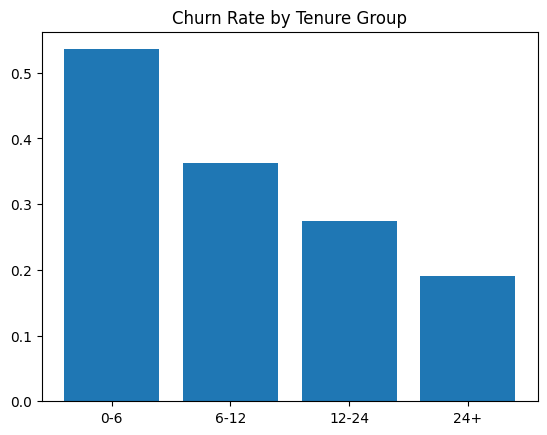

In [28]:
# Step 5: Visualize (important)
import matplotlib.pyplot as plt

plt.figure()
plt.bar(tenure_analysis['tenure_group'], tenure_analysis['Churn'])
plt.title("Churn Rate by Tenure Group")
plt.show()

PART 1: Churn Risk Segmentation

In [30]:
# Step 1: Get churn probabilities
# knn = KNeighborsClassifier(n_neighbors=3)
# rfc = RandomForestClassifier(n_estimators = 7,
#                              criterion = 'entropy',
#                              random_state =7)
# svc = SVC()
# lc = LogisticRegression(max_iter=1000)
# for clf in (rfc):
#     clf.fit(X_train_1, y_train)
y_prob = rfc.predict_proba(X_test_1)[:, 1]  # probability of churn
y_prob

array([1.        , 0.14285714, 0.        , ..., 0.        , 0.        ,
       0.14285714])

In [32]:
# Step 2: Create dataframe
# 1. Convert the NumPy array back to a DataFrame
# Use the same feature names you used for X_train
results_df = pd.DataFrame(X_test_1, columns=feature_list)

# 2. Now these assignments will work perfectly
results_df['Actual_Churn'] = y_test.values
results_df['Churn_Probability'] = y_prob

# 3. View the first few rows
print(results_df.head())

     gender  SeniorCitizen   Partner  Dependents    tenure  PhoneService  \
0 -1.025166      -0.437749  1.031376   -0.652662 -1.284605     -3.034225   
1  0.975452      -0.437749 -0.969579   -0.652662  0.353238      0.329573   
2 -1.025166      -0.437749  1.031376    1.532186  0.803645      0.329573   
3 -1.025166      -0.437749 -0.969579   -0.652662 -1.284605      0.329573   
4  0.975452      -0.437749 -0.969579   -0.652662  1.417836      0.329573   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0       0.053901        -1.182347       -0.915399     -1.038357  ...   
1       1.108339         1.531583        0.247740      0.095824  ...   
2      -1.000537         1.531583        0.247740      0.095824  ...   
3      -1.000537         0.174618       -0.915399     -1.038357  ...   
4      -1.000537        -1.182347       -0.915399     -1.038357  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0    -0.921484    -1.117461       

In [33]:
# Step 3: Create risk segments
def risk_segment(prob):
    if prob > 0.7:
        return 'High Risk'
    elif prob > 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results_df['Risk_Segment'] = results_df['Churn_Probability'].apply(risk_segment)

In [34]:
# Step 4: Distribution of customers
segment_distribution = results_df['Risk_Segment'].value_counts(normalize=True) * 100
print(segment_distribution)

Risk_Segment
Low Risk       68.346345
Medium Risk    18.523776
High Risk      13.129879
Name: proportion, dtype: float64


In [35]:
# Step 5: Churn rate per segment (THIS IS IMPORTANT)
churn_by_segment = results_df.groupby('Risk_Segment')['Actual_Churn'].mean().reset_index()
print(churn_by_segment)

  Risk_Segment  Actual_Churn
0    High Risk      0.675676
1     Low Risk      0.138110
2  Medium Risk      0.440613


In [36]:
# Step 6: Combine both (final insight)
final_segment = results_df.groupby('Risk_Segment').agg(
    Customers=('Risk_Segment', 'count'),
    Churn_Rate=('Actual_Churn', 'mean')
).reset_index()

print(final_segment)

  Risk_Segment  Customers  Churn_Rate
0    High Risk        185    0.675676
1     Low Risk        963    0.138110
2  Medium Risk        261    0.440613


In [40]:
# PART 2: Revenue Impact Analysis
# You NEED a revenue column (example: MonthlyCharges or Revenue)
# 1. Reverse the scaling to get original dollar amounts
X_test_unscaled = scaler.inverse_transform(X_test_1)

# 2. Create the DataFrame using the unscaled data
X_test_1_df = pd.DataFrame(X_test_unscaled, columns=feature_list)

# 3. Now the 'Revenue' (MonthlyCharges) will be in real dollars
results_df['Revenue'] = X_test_1_df['MonthlyCharges']

# 4. Grouping will now show positive dollar amounts
revenue_by_segment = results_df.groupby('Risk_Segment')['Revenue'].sum().reset_index()
print(revenue_by_segment)


# Step 3: Potential revenue loss
# Only consider customers likely to churn
results_df['Potential_Loss'] = results_df['Revenue'] * results_df['Churn_Probability']

loss_by_segment = results_df.groupby('Risk_Segment')['Potential_Loss'].sum().reset_index()

print(loss_by_segment)
# Step 4: Top risky customers (THIS IS GOLD)
top_risky = results_df.sort_values(by='Churn_Probability', ascending=False)

top_20_percent = top_risky.head(int(0.2 * len(top_risky)))

top_20_revenue = top_20_percent['Revenue'].sum()
total_revenue = results_df['Revenue'].sum()

print("Top 20% risky customers revenue %:", (top_20_revenue / total_revenue) * 100)
# Step 5: Segment + revenue combined
final_business = results_df.groupby('Risk_Segment').agg(
    Customers=('Risk_Segment', 'count'),
    Churn_Rate=('Actual_Churn', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Potential_Loss=('Potential_Loss', 'sum')
).reset_index()

print(final_business)


  Risk_Segment   Revenue
0    High Risk  14225.70
1     Low Risk  56849.95
2  Medium Risk  19595.75
  Risk_Segment  Potential_Loss
0    High Risk    11948.908793
1     Low Risk     6198.120476
2  Medium Risk     9505.811905
Top 20% risky customers revenue %: 23.653820278500167
  Risk_Segment  Customers  Churn_Rate  Total_Revenue  Potential_Loss
0    High Risk        185    0.675676       14225.70    11948.908793
1     Low Risk        963    0.138110       56849.95     6198.120476
2  Medium Risk        261    0.440613       19595.75     9505.811905


8.1 SMOTE MODEL TRAINING

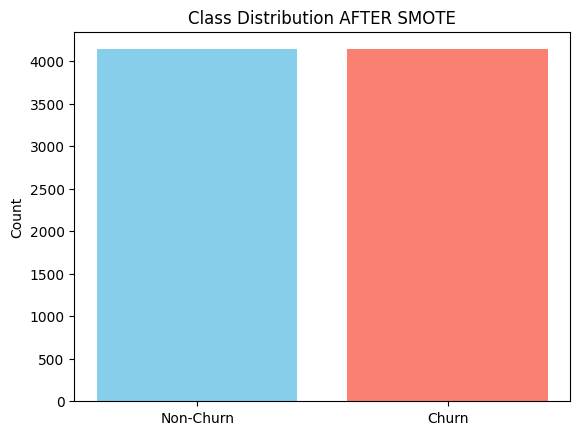

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Churn', 'Churn'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

SMOTE TEST SET

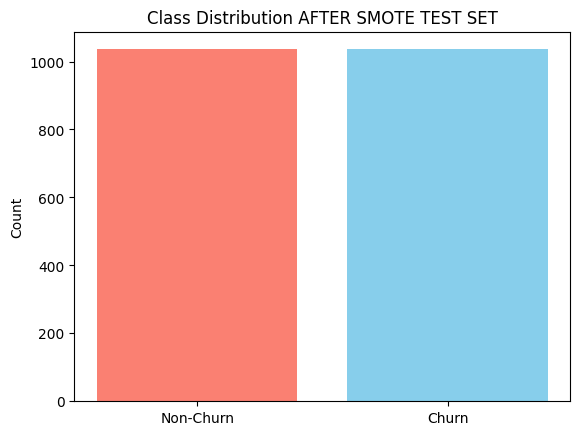

In [ ]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_test_sm, y_test_sm = smote.fit_resample(X_test, y_test)
plt.bar(y_test_sm.value_counts().index, y_test_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Churn', 'Churn'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE TEST SET")
plt.show()

8.2 SMOTE MODEL TRAINING AND PERFORMANCE

In [ ]:
# making predictions on the training set
for clf in (rfc, knn, svc,lc):
    clf.fit(X_train_sm, y_train_sm)
    y_pred_sm = clf.predict(X_train_sm)
    print("Accuracy score of ",
          clf.__class__.__name__,
          "=",100*metrics.accuracy_score(y_train_sm,
                                         y_pred_sm))




# model.fit(X_train_sm, y_train_sm)

# y_pred_sm = model.predict(X_test)

# print("Accuracy AFTER SMOTE:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
# print("Classification Report AFTER SMOTE:\n", classification_report(y_test, y_pred_sm))

# sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix AFTER SMOTE")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

Accuracy score of  RandomForestClassifier = 98.5621072982117
Accuracy score of  KNeighborsClassifier = 89.42725954567425
Accuracy score of  SVC = 83.60318994683422
Accuracy score of  LogisticRegression = 77.16288061865636


## 9. Model Evaluation

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.62      0.48      0.54       373

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



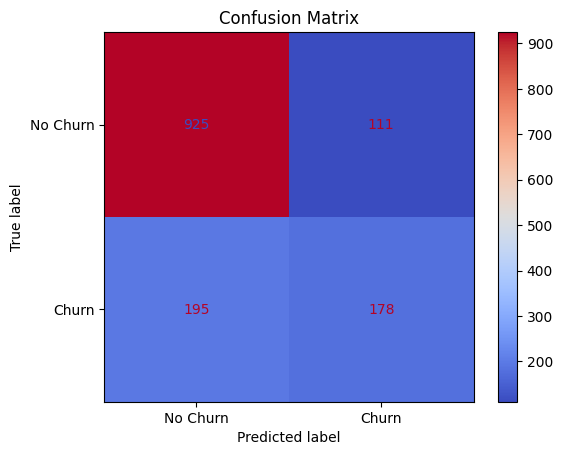

Accuracy score of  RandomForestClassifier = 78.28246983676365
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1036
           1       0.51      0.47      0.49       373

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.74      0.74      1409



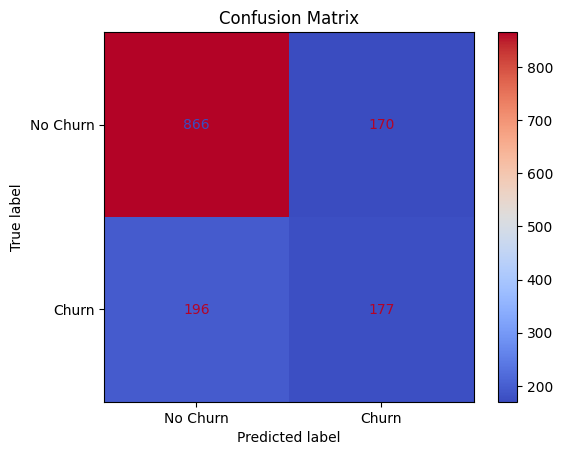

Accuracy score of  KNeighborsClassifier = 74.02413058907025
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



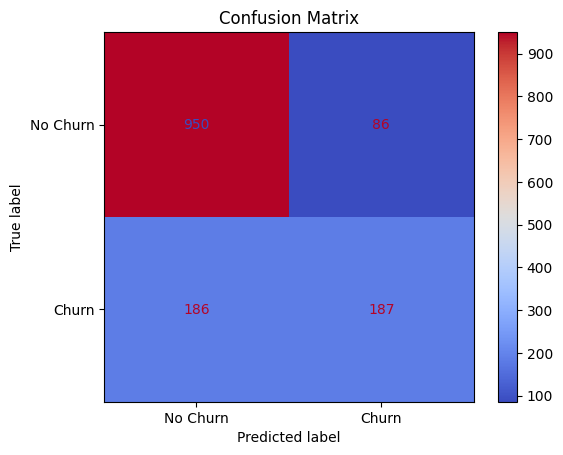

Accuracy score of  SVC = 80.69552874378992
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



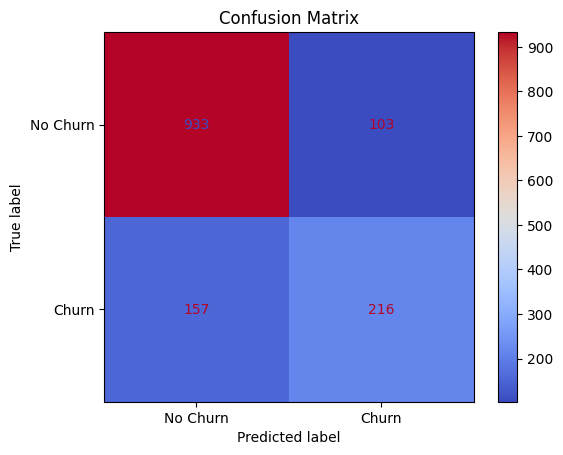

Accuracy score of  LogisticRegression = 81.5471965933286


In [43]:
# pred = model.predict(X_test)
# print('Accuracy:', accuracy_score(y_test, pred))
# print(confusion_matrix(y_test, pred))
# print(classification_report(y_test, pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report



# making predictions on the testing set
for clf in (rfc, knn, svc,lc):
    clf.fit(X_train_1, y_train)
    y_pred = clf.predict(X_test_1)
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(cmap="coolwarm")
    plt.title('Confusion Matrix')
    plt.show()
    print("Accuracy score of ",
          clf.__class__.__name__,"=",
          100*metrics.accuracy_score(y_test,
                                     y_pred))
    # print(confusion_matrix(y_test, y_pred))

9.1 MODEL EVALUATION SMOTE TEST SET

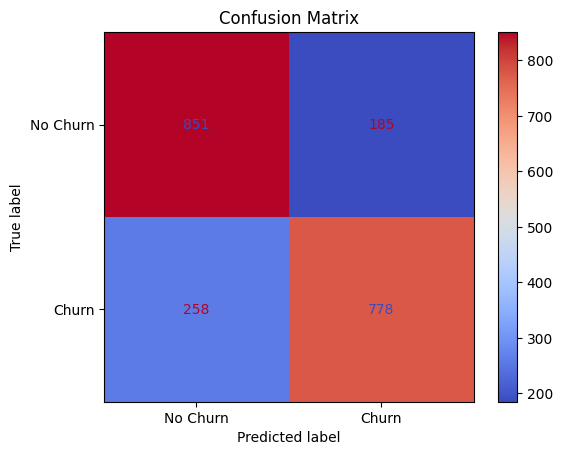

Accuracy score of  RandomForestClassifier = 78.61969111969111


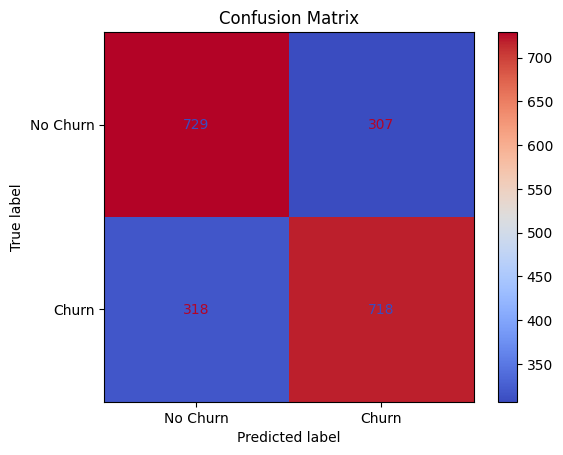

Accuracy score of  KNeighborsClassifier = 69.83590733590734


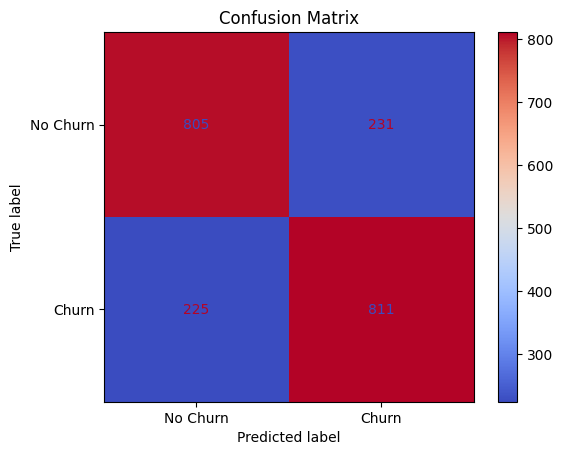

Accuracy score of  SVC = 77.99227799227799


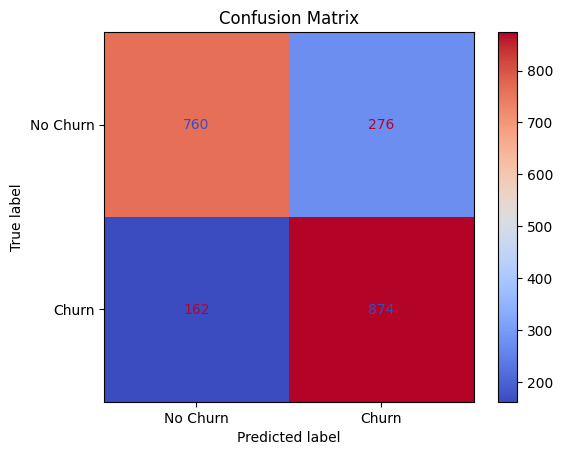

Accuracy score of  LogisticRegression = 78.86100386100387


In [ ]:
# pred = model.predict(X_test)
# print('Accuracy:', accuracy_score(y_test, pred))
# print(confusion_matrix(y_test, pred))
# print(classification_report(y_test, pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# making predictions on the testing set
for clf in (rfc, knn, svc,lc):
    clf.fit(X_train_sm, y_train_sm)
    y_pred_sm = clf.predict(X_test_sm)
    cm = confusion_matrix(y_test_sm, y_pred_sm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(cmap="coolwarm")
    plt.title('Confusion Matrix')
    plt.show()
    print("Accuracy score of ",
          clf.__class__.__name__,"=",
          100*metrics.accuracy_score(y_test_sm,
                                     y_pred_sm))
    # print(confusion_matrix(y_test, y_pred))

## 10. Business Insights
Explain what factors lead to churn and what actions a company can take.

Memorize just this:

Recall = how many churners you correctly caught
Precision = how accurate your churn predictions are
Two simple examples:

High accuracy + low recall = useless churn model
High recall = better at catching churners (this matters more)
Your strongest part is NOT the model
Your strength is:
Segmentation,
Revenue impact

That’s what you should talk more about.
🧠 If interviewer pushes you

Use this:

Example 1:
“My focus was not just prediction accuracy but identifying high-risk customers and quantifying revenue at risk.”

Example 2:
“The model helped isolate a small high-risk segment driving majority of churn, which is more actionable for business.”